<a href="https://colab.research.google.com/github/Huhhuu/DataDeepLearning/blob/main/TH_DEEPLEARNING_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#HUONG DAN CAI DAT CNN
CAI DAT CNN

nap thu vien

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import keras
from keras.layers import Conv2D, Dense, MaxPool2D, Flatten
from keras.models import Sequential
from keras import Input

# data visualization packages
import matplotlib.pyplot as plt

#Doc di lieu mnist_test

Sử dụng bộ dữ liệu MNIST được cung cấp sẵn trong thư mục sample_data của Google Colab.

In [2]:
mnist_train = '/content/sample_data/mnist_train_small.csv'
mnist_test = '/content/sample_data/mnist_test.csv'

df_train = pd.read_csv(mnist_train)
df_test = pd.read_csv(mnist_test)

print(df_train.shape)

X_train = df_train.iloc[:,1:]
y_train = df_train.iloc[:,0]

X_test = df_test.iloc[:,1:]
y_test = df_test.iloc[:,0]

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(19999, 785)
(19999, 784) (19999,) (9999, 784) (9999,)


Bộ dữ liệu huấn luyện gồm 19.999 mẫu. Mỗi mẫu có 785 thuộc tính, bao gồm 1 nhãn và 784 giá trị điểm ảnh.

Tách dữ liệu thành hai phần gồm X là các đặc trưng ảnh và y là nhãn cần dự đoán. Sau khi tách, tập huấn luyện có kích thước (19999, 784) và tập kiểm thử có kích thước (9999, 784), sẵn sàng cho bước tiền xử lý và xây dựng mô hình CNN.

#Tien xu ly du lieu

In [3]:
num_classes = 10
input_shape = (28, 28, 1)

X_train = X_train.astype("float32")/255
X_test = X_test.astype("float32")/255

X_train = X_train.to_numpy()
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
print(X_train.shape)

X_test = X_test.to_numpy()
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)
print(X_test.shape)

print('Number of classes:', len(np.unique(y_train)))
print('Classes:', np.unique(y_train))
print(y_train[:5])

(19999, 28, 28, 1)
(9999, 28, 28, 1)
Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]
0    5
1    7
2    9
3    5
4    2
Name: 6, dtype: int64


Sau khi đọc dữ liệu, em tiến hành tiền xử lý để phù hợp với mô hình CNN. Đầu tiên em khai báo số lớp phân loại là 10 tương ứng với các chữ số từ 0 đến 9 và kích thước ảnh đầu vào là 28×28×1. Tiếp theo em chuẩn hóa giá trị điểm ảnh từ khoảng 0–255 về 0–1 bằng cách chia cho 255 để giúp mô hình học hiệu quả hơn. Sau đó em chuyển dữ liệu từ DataFrame sang NumPy Array và thực hiện reshape từ dạng 784 pixel thành ảnh có kích thước 28×28×1. Cuối cùng em kiểm tra lại số lớp và các nhãn trong tập dữ liệu để đảm bảo dữ liệu đã sẵn sàng cho quá trình xây dựng và huấn luyện mô hình CNN.

#Truc quan hoa 10 anh dau tien

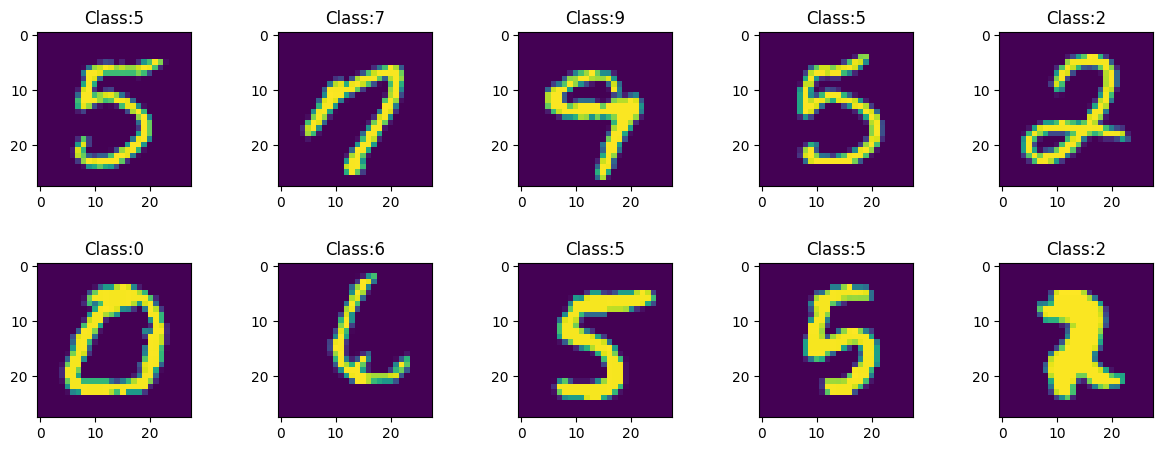

In [4]:
# Data visualization
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15,5))
ax = axes.ravel()

for i in range(10):
    ax[i].imshow(X_train[i].reshape(28,28))
    ax[i].title.set_text('Class:' + str(y_train[i]))

plt.subplots_adjust(hspace=0.5)
plt.show()

Ở bước này em sử dụng thư viện Matplotlib để trực quan hóa 10 ảnh đầu tiên trong tập huấn luyện. Em tạo một lưới gồm 2 hàng và 5 cột để hiển thị ảnh. Mỗi ảnh được chuyển từ dạng vector 784 pixel về ma trận 28×28 và hiển thị bằng hàm imshow. Đồng thời em hiển thị nhãn tương ứng của từng ảnh bằng tiêu đề Class để kiểm tra tính chính xác của dữ liệu. Việc trực quan hóa giúp xác nhận rằng dữ liệu đã được tiền xử lý đúng và sẵn sàng cho quá trình huấn luyện mô hình CNN.

#Chuyển giá trị nhãn thành One-Hot Encoding

In [5]:
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

Ở bước này em chuyển đổi các nhãn từ dạng số nguyên sang dạng One-Hot Encoding bằng hàm to_categorical() của Keras. Vì bộ dữ liệu MNIST gồm 10 lớp từ 0 đến 9 nên mỗi nhãn sẽ được biểu diễn bởi một vector gồm 10 phần tử, trong đó chỉ có một vị trí mang giá trị 1 tương ứng với lớp của ảnh.

#Xay dung mo hinh CNN

In [6]:
model = Sequential()

model.add(Input(shape=input_shape))

model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(units=10, activation='softmax'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

Ở bước này em xây dựng mô hình CNN bằng Keras theo kiến trúc Sequential. Đầu tiên mô hình nhận ảnh đầu vào kích thước 28×28×1. Sau đó ảnh được đưa qua hai lớp tích chập Conv2D với lần lượt 32 và 64 bộ lọc kích thước 3×3 để trích xuất các đặc trưng từ đơn giản đến phức tạp. Sau mỗi lớp tích chập là một lớp MaxPooling 2×2 nhằm giảm kích thước dữ liệu và tăng hiệu quả tính toán. Tiếp theo lớp Flatten chuyển dữ liệu nhiều chiều thành vector một chiều. Cuối cùng lớp Dense gồm 10 neuron kết hợp với hàm Softmax để thực hiện phân loại 10 chữ số từ 0 đến 9. Sau khi xây dựng xong, em sử dụng hàm summary để kiểm tra kiến trúc và số lượng tham số của mô hình.

#Huan luyen mo hinh CNN

In [7]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_fit = model.fit(
    X_train,
    y_train,
    batch_size=128,
    epochs=15,
    validation_split=0.1,
    verbose=1
)

Epoch 1/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 9s 58ms/step - accuracy: 0.8284 - loss: 0.6031 - val_accuracy: 0.9410 - val_loss: 0.2027
Epoch 2/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 8s 56ms/step - accuracy: 0.9552 - loss: 0.1534 - val_accuracy: 0.9635 - val_loss: 0.1304
Epoch 3/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 13s 73ms/step - accuracy: 0.9689 - loss: 0.0997 - val_accuracy: 0.9645 - val_loss: 0.1095
Epoch 4/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 17s 49ms/step - accuracy: 0.9760 - loss: 0.0775 - val_accuracy: 0.9730 - val_loss: 0.0953
Epoch 5/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 9s 61ms/step - accuracy: 0.9796 - loss: 0.0647 - val_accuracy: 0.9735 - val_loss: 0.0812
Epoch 6/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 8s 54ms/step - accuracy: 0.9831 - loss: 0.0541 - val_accuracy: 0.9750 - val_loss: 0.0801
Epoch 7/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - accuracy: 0.9858 - loss: 0.0462 - val_accuracy: 0.9765 - val_loss: 0.0798
Epoch 8/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - accuracy: 0.9862 - loss: 0.0423 - val_

Sau khi xây dựng mô hình CNN, em tiến hành cấu hình mô hình bằng hàm compile. Trong đó em sử dụng Adam làm thuật toán tối ưu, hàm loss Categorical Crossentropy cho bài toán phân loại nhiều lớp và Accuracy để đánh giá độ chính xác. Tiếp theo em huấn luyện mô hình bằng hàm fit với batch size là 128 và số epoch là 15. Đồng thời em dành 10% dữ liệu huấn luyện làm tập Validation để theo dõi hiệu năng của mô hình trong quá trình học. Kết quả huấn luyện sẽ cho biết sự thay đổi của Loss và Accuracy qua từng Epoch, từ đó đánh giá khả năng học của mô hình CNN.

#Danh gia mo hinh

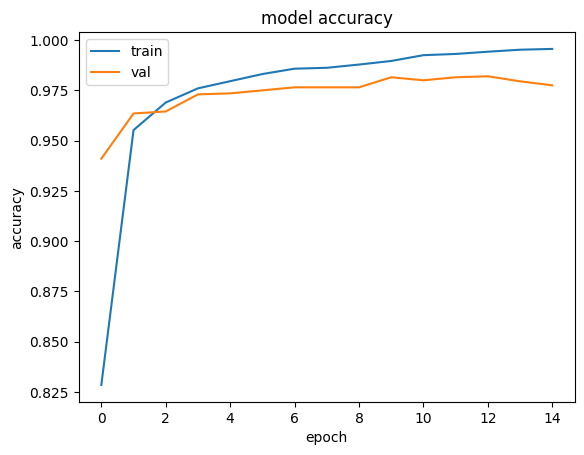

In [8]:
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])

plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')

plt.legend(['train', 'val'], loc='upper left')

plt.show()

Sau khi huấn luyện, em sử dụng Matplotlib để vẽ biểu đồ độ chính xác của mô hình theo từng Epoch. Đường thứ nhất biểu diễn Accuracy trên tập huấn luyện, còn đường thứ hai biểu diễn Accuracy trên tập Validation. Thông qua biểu đồ, em có thể quan sát khả năng học của mô hình và kiểm tra xem mô hình có bị Overfitting hay không. Nếu hai đường cùng tăng và có giá trị gần nhau thì mô hình học tốt và có khả năng tổng quát hóa cao trên dữ liệu mới.

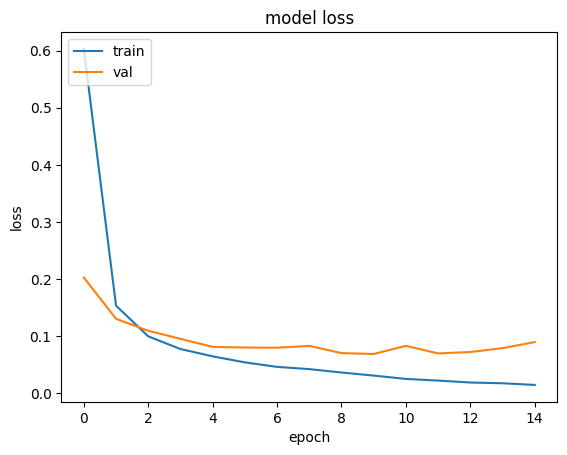

In [9]:
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])

plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')

plt.legend(['train', 'val'], loc='upper left')

plt.show()

Sau khi đánh giá Accuracy, em tiếp tục theo dõi Loss của mô hình trên tập huấn luyện và tập Validation. Loss thể hiện mức độ sai lệch giữa kết quả dự đoán và nhãn thực tế, vì vậy giá trị càng nhỏ thì mô hình càng hoạt động tốt. Thông qua biểu đồ, nếu cả Train Loss và Validation Loss cùng giảm theo thời gian và có giá trị gần nhau thì mô hình đang học hiệu quả. Ngược lại, nếu Train Loss tiếp tục giảm nhưng Validation Loss tăng thì mô hình có dấu hiệu Overfitting. Biểu đồ này giúp em đánh giá chất lượng và khả năng tổng quát hóa của mô hình CNN.

#Danh gia mo hinh CNN thu nghiem tren tap text

In [12]:
score = model.evaluate(
    X_test,
    y_test,
    verbose=2
)

print('Test loss:', score[0])
print('Test accuracy:', score[1])

313/313 - 1s - 5ms/step - accuracy: 0.9816 - loss: 0.0732
Test loss: 0.07318798452615738
Test accuracy: 0.9815981388092041


Sau khi huấn luyện mô hình CNN, em sử dụng hàm evaluate để đánh giá trên tập Test. Kết quả cho thấy Test Loss đạt khoảng 0.0731 và Test Accuracy đạt khoảng 98.15%. Điều này chứng tỏ mô hình có khả năng nhận dạng chữ số viết tay rất tốt với tỷ lệ dự đoán đúng 98%.

#Du doan bao nhan

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
[[3.9579911e-04 4.7827981e-04 9.9912590e-01 3.9873504e-10 1.8236483e-18
  9.6902439e-14 1.7983250e-08 9.2951320e-16 1.6148146e-08 1.2521690e-19]]
2 2


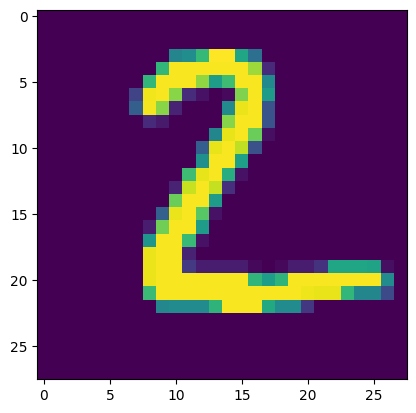

In [24]:
predict = model.predict(X_test[:1])

print(predict)

print(
    np.argmax(predict),
    np.argmax(y_test[0])
)

plt.imshow(
    X_test[:1].reshape(28,28)
)

plt.show()

Ở bước cuối cùng, em sử dụng mô hình CNN đã huấn luyện để dự đoán nhãn của một ảnh trong tập Test. Hàm predict() trả về xác suất thuộc về từng lớp từ 0 đến 9. Sau đó em sử dụng hàm argmax() để lấy lớp có xác suất cao nhất làm kết quả dự đoán. Đồng thời em cũng lấy nhãn thực tế của ảnh để so sánh. Cuối cùng em hiển thị ảnh đầu vào bằng Matplotlib nhằm kiểm chứng trực quan kết quả nhận dạng. Nếu nhãn dự đoán trùng với nhãn thực tế thì mô hình đã nhận dạng chính xác ảnh chữ số đó.

#Luu lai tham so mo hinh CNN

In [27]:
model.save_weights('cnn.weights.h5')

#Nap lai mo hinh va tham so

Saving Untitled.png to Untitled (3).png


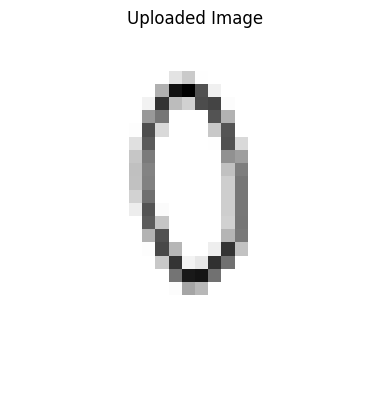

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Dự đoán là số: 0

Xác suất:
So 0: 86.17%
So 1: 0.40%
So 2: 2.55%
So 3: 0.11%
So 4: 0.07%
So 5: 0.04%
So 6: 0.64%
So 7: 0.02%
So 8: 7.68%
So 9: 2.34%


In [117]:
from google.colab import files
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

uploaded = files.upload()

for filename in uploaded.keys():

    img = Image.open(filename)

    img = img.convert('L')

    img = img.resize((28, 28))

    img_array = np.array(img)

    img_array = 255 - img_array

    img_array = img_array.astype("float32") / 255.0

    plt.imshow(img_array, cmap='gray')
    plt.title("Uploaded Image")
    plt.axis("off")
    plt.show()

    img_array = img_array.reshape(1, 28, 28, 1)

    predict = model.predict(img_array)

    predicted_digit = np.argmax(predict)

    print("Dự đoán là số:", predicted_digit)

    print("\nXác suất:")
    for i in range(10):
        print(
            f"So {i}: {predict[0][i]*100:.2f}%"
        )

Ở bước này em kiểm tra khả năng tái sử dụng mô hình bằng cách khởi tạo lại CNN với cùng kiến trúc và nạp các trọng số đã lưu trong file cnn.weights.h5. Sau đó em sử dụng một ảnh trong tập kiểm tra để dự đoán. Kết quả cho thấy nhãn dự đoán trùng với nhãn thực tế, chứng minh rằng việc lưu và nạp lại trọng số đã thành công. Điều này giúp tiết kiệm thời gian vì không cần huấn luyện lại mô hình khi muốn sử dụng trong tương lai hoặc triển khai vào ứng dụng thực tế.

==========================================================

#Viết chương trình cài đặt CNN để nhận dạng ảnh trên bộ dataset CIFAR10 có sẵn trong tensorflow với các nhãn sau

# 1. Nạp thư viện

In [30]:
import tensorflow as tf
from tensorflow import keras
from keras import layers
import matplotlib.pyplot as plt
import numpy as np

# 2. Đọc dữ liệu CIFAR-10

In [31]:
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
(50000, 32, 32, 3)
(50000, 1)
(10000, 32, 32, 3)
(10000, 1)


# 3. Khai báo nhãn

In [32]:
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

num_classes = 10
input_shape = (32, 32, 3)

# 4. Chuẩn hóa dữ liệu

In [33]:
X_train = X_train.astype("float32") / 255
X_test = X_test.astype("float32") / 255

y_train_cat = keras.utils.to_categorical(y_train, num_classes)
y_test_cat = keras.utils.to_categorical(y_test, num_classes)

# 5. Trực quan hóa 10 ảnh đầu tiên

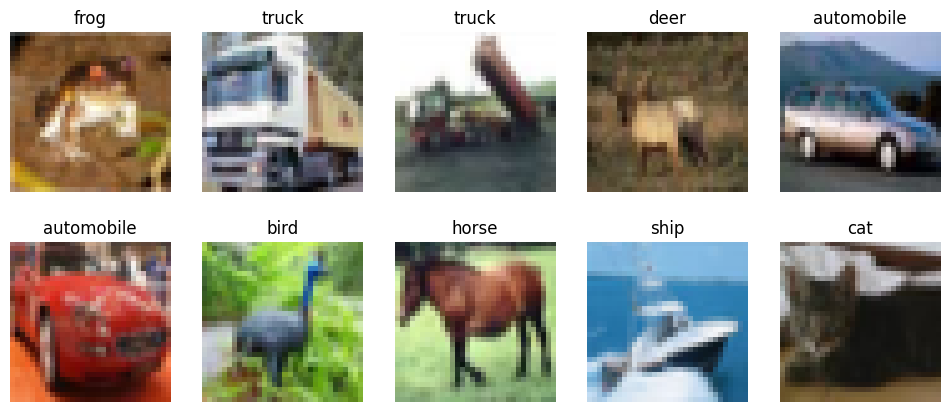

In [34]:
plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.show()

# 6. Xây dựng mô hình CNN


In [35]:
model = keras.Sequential([
    keras.Input(shape=input_shape),

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

# 7. Compile mô hình

In [36]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 8. Huấn luyện mô hình


In [37]:
model_fit = model.fit(
    X_train,
    y_train_cat,
    batch_size=64,
    epochs=15,
    validation_split=0.1,
    verbose=1
)

Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 71s 99ms/step - accuracy: 0.4539 - loss: 1.5029 - val_accuracy: 0.5578 - val_loss: 1.2318
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 77s 92ms/step - accuracy: 0.6169 - loss: 1.0806 - val_accuracy: 0.6596 - val_loss: 0.9832
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 76s 84ms/step - accuracy: 0.6877 - loss: 0.8967 - val_accuracy: 0.6846 - val_loss: 0.9012
Epoch 4/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 83ms/step - accuracy: 0.7275 - loss: 0.7863 - val_accuracy: 0.7270 - val_loss: 0.8091
Epoch 5/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 59s 83ms/step - accuracy: 0.7585 - loss: 0.6919 - val_accuracy: 0.7368 - val_loss: 0.7634
Epoch 6/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 58s 82ms/step - accuracy: 0.7833 - loss: 0.6223 - val_accuracy: 0.7462 - val_loss: 0.7691
Epoch 7/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 58s 82ms/step - accuracy: 0.8076 - loss: 0.5509 - val_accuracy: 0.7514 - val_loss: 0.7498
Epoch 8/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 59s 84ms/step - accuracy: 0.8285 - loss: 0.4862 - 

# 9. Vẽ biểu đồ Accuracy


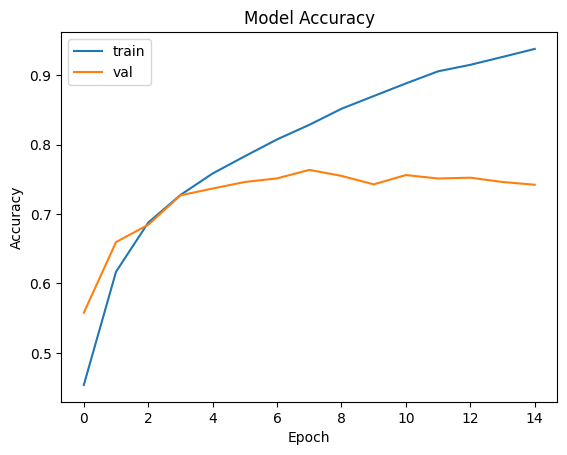

In [38]:
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

# 10. Vẽ biểu đồ Loss


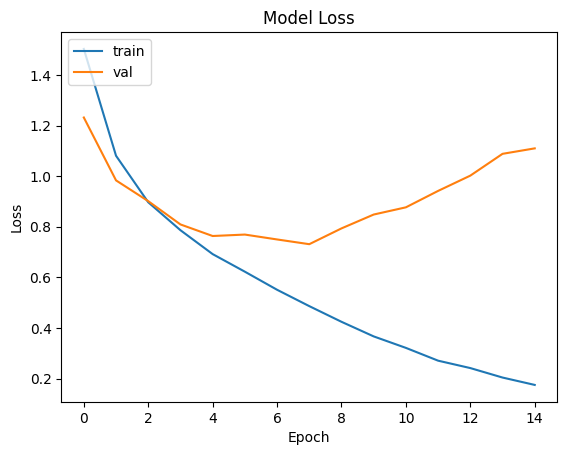

In [39]:
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

# 11. Đánh giá trên tập Test


In [40]:
score = model.evaluate(X_test, y_test_cat, verbose=2)

print('Test loss:', score[0])
print('Test accuracy:', score[1])

313/313 - 4s - 13ms/step - accuracy: 0.7229 - loss: 1.2302
Test loss: 1.2302199602127075
Test accuracy: 0.7228999733924866


# 12. Dự đoán thử 1 ảnh


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Dự đoán: 2 - bird
Nhãn thật: 2 - bird


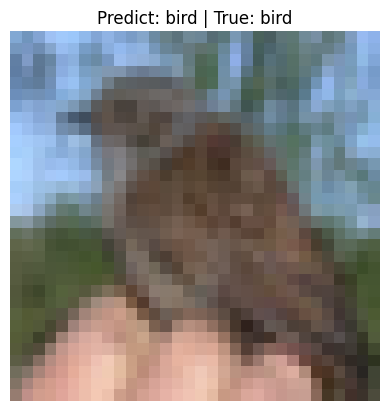

In [58]:
index = 1356

predict = model.predict(X_test[index:index+1])

pred_label = np.argmax(predict)
true_label = y_test[index][0]

print("Dự đoán:", pred_label, "-", class_names[pred_label])
print("Nhãn thật:", true_label, "-", class_names[true_label])

plt.imshow(X_test[index])
plt.title("Predict: " + class_names[pred_label] + " | True: " + class_names[true_label])
plt.axis("off")
plt.show()

# 13. Lưu trọng số mô hình

In [54]:
model.save_weights('cifar10_cnn.weights.h5')

# 14. Nạp lại mô hình và trọng số


In [55]:
new_model = keras.Sequential([
    keras.Input(shape=input_shape),

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

new_model.load_weights('cifar10_cnn.weights.h5')

# 15. Dự đoán lại bằng mô hình đã nạp


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Dự đoán: 8 - ship
Nhãn thật: 0 - airplane


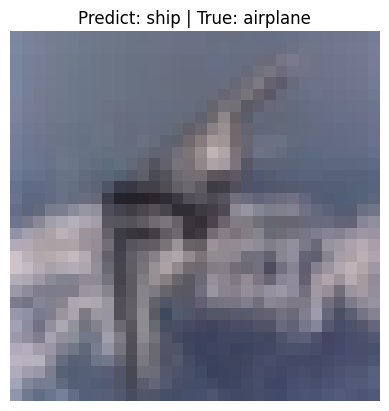

In [62]:
index = 5354

predict = new_model.predict(X_test[index:index+1])

pred_label = np.argmax(predict)
true_label = y_test[index][0]

print("Dự đoán:", pred_label, "-", class_names[pred_label])
print("Nhãn thật:", true_label, "-", class_names[true_label])

plt.imshow(X_test[index])
plt.title("Predict: " + class_names[pred_label] + " | True: " + class_names[true_label])
plt.axis("off")
plt.show()

========================================================

#Chuong trinh CNN nhan dang anh CAT hoac DOG

# 1. Cài và nạp thư viện

In [63]:
!pip install tensorflow-datasets -q

import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np

# 2. Tải dataset Cats vs Dogs online

In [64]:
(ds_train, ds_val, ds_test), ds_info = tfds.load(
    'cats_vs_dogs',
    split=['train[:80%]', 'train[80%:90%]', 'train[90%:]'],
    as_supervised=True,
    with_info=True
)

print(ds_info)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.FDS1ZM_4.0.1/cats_vs_dogs-train.tfrecord-[0-9][0-9…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.
tfds.core.DatasetInfo(
    name='cats_vs_dogs',
    full_name='cats_vs_dogs/4.0.1',
    description="""
    A large set of images of cats and dogs. There are 1738 corrupted images that are dropped.
    """,
    homepage='https://www.microsoft.com/en-us/download/details.aspx?id=54765',
    data_dir='/root/tensorflow_datasets/cats_vs_dogs/4.0.1',
    file_format=tfrecord,
    download_size=786.67 MiB,
    dataset_size=1.04 GiB,
    features=FeaturesDict({
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'image/filename': Text(shape=(), dtype=string),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=2),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'train': <SplitInfo num_examples=23262, num_shards=16>,
    },
    citation="""@Inproceedings 

# 3. Khai báo thông tin ảnh


In [65]:
IMG_SIZE = 128
BATCH_SIZE = 32

class_names = ['cat', 'dog']

# 4. Tiền xử lý dữ liệu


In [66]:
def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

train_data = ds_train.map(preprocess).shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_data = ds_val.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_data = ds_test.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# 5. Trực quan hóa một số ảnh


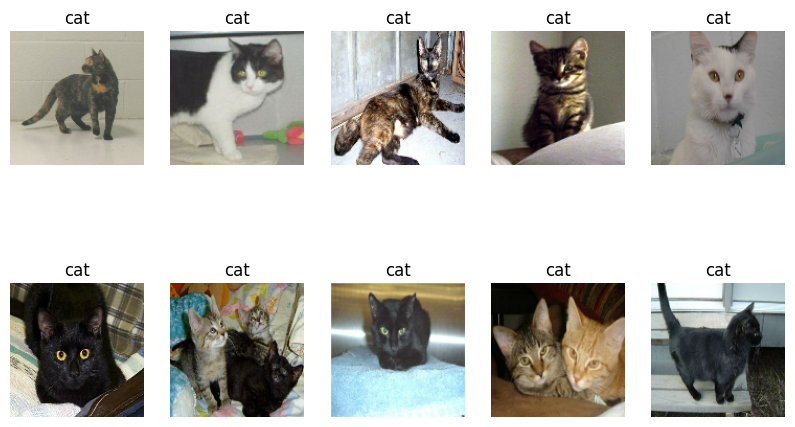

In [67]:
plt.figure(figsize=(10, 6))

for images, labels in train_data.take(1):
    for i in range(10):
        plt.subplot(2, 5, i + 1)
        plt.imshow(images[i])
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

# 6. Xây dựng mô hình CNN


In [68]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

# 7. Compile mô hình


In [69]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 8. Huấn luyện mô hình


In [70]:
history = model.fit(
    train_data,
    epochs=10,
    validation_data=val_data
)

Epoch 1/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 371s 634ms/step - accuracy: 0.6402 - loss: 0.6318 - val_accuracy: 0.7451 - val_loss: 0.5457
Epoch 2/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 357s 613ms/step - accuracy: 0.7527 - loss: 0.5101 - val_accuracy: 0.7653 - val_loss: 0.4847
Epoch 3/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 356s 611ms/step - accuracy: 0.7901 - loss: 0.4515 - val_accuracy: 0.7885 - val_loss: 0.4424
Epoch 4/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 359s 615ms/step - accuracy: 0.8217 - loss: 0.3968 - val_accuracy: 0.8095 - val_loss: 0.4133
Epoch 5/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 366s 625ms/step - accuracy: 0.8465 - loss: 0.3502 - val_accuracy: 0.8194 - val_loss: 0.4028
Epoch 6/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 365s 625ms/step - accuracy: 0.8696 - loss: 0.3053 - val_accuracy: 0.8362 - val_loss: 0.3854
Epoch 7/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 364s 625ms/step - accuracy: 0.8930 - loss: 0.2545 - val_accuracy: 0.8457 - val_loss: 0.3997
Epoch 8/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 353s 606ms/step - accuracy: 0.9118 -

# 9. Vẽ biểu đồ Accuracy

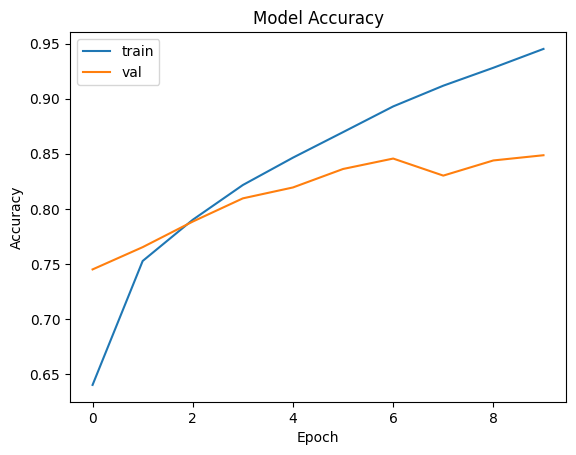

In [71]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

# 10. Vẽ biểu đồ Loss


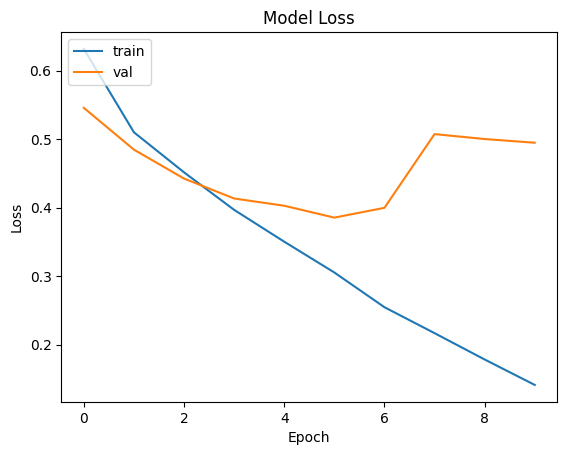

In [72]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

# 11. Đánh giá trên tập Test


In [73]:
score = model.evaluate(test_data, verbose=2)

print("Test loss:", score[0])
print("Test accuracy:", score[1])

73/73 - 14s - 190ms/step - accuracy: 0.8573 - loss: 0.4474
Test loss: 0.4474433362483978
Test accuracy: 0.8572657108306885


# 12. Dự đoán thử 1 ảnh


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Xác suất dự đoán: 0.00048847083
Dự đoán: cat
Nhãn thật: cat


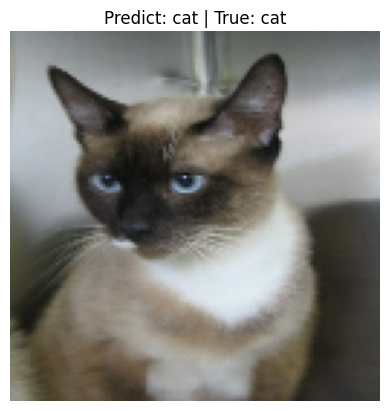

In [86]:
for images, labels in test_data.take(1):
    img = images[0]
    true_label = labels[0].numpy()

    predict = model.predict(tf.expand_dims(img, axis=0))
    pred_label = 1 if predict[0][0] >= 0.5 else 0

    print("Xác suất dự đoán:", predict[0][0])
    print("Dự đoán:", class_names[pred_label])
    print("Nhãn thật:", class_names[true_label])

    plt.imshow(img)
    plt.title("Predict: " + class_names[pred_label] + " | True: " + class_names[true_label])
    plt.axis("off")
    plt.show()

# 13. Lưu mô hình


In [87]:
model.save('cat_dog_cnn.keras')

# 14. Nạp lại mô hình


In [88]:
loaded_model = tf.keras.models.load_model('cat_dog_cnn.keras')

#=============================

#Hãy viết chương trình cài đặt CNN để nhận dạng ảnh Fashion-MNIST

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 28s 64ms/step - accuracy: 0.8031 - loss: 0.5522 - val_accuracy: 0.8528 - val_loss: 0.4062
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 39s 60ms/step - accuracy: 0.8721 - loss: 0.3557 - val_accuracy: 0.8763 - val_loss: 0.3439
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 58ms/step - accuracy: 0.8879 - loss: 0.3096 - val_accuracy: 0.8793 - val_loss: 0.3241
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 25s 58ms/step - accuracy: 0.8963 - loss: 0.2835 - val_accuracy: 0.8918 - val_loss: 0.2902
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 42s 61ms/step - accuracy: 0.9071 - loss: 0.2585 - val_accuracy: 0.8972 - val_loss: 0.2819
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 60ms/step - accuracy: 0.9112 - loss: 0.2417 - val_accuracy: 0.9032 - val_loss: 0.2644
Epoch 7/10
422/422 ━━━━━━━━━━━━━

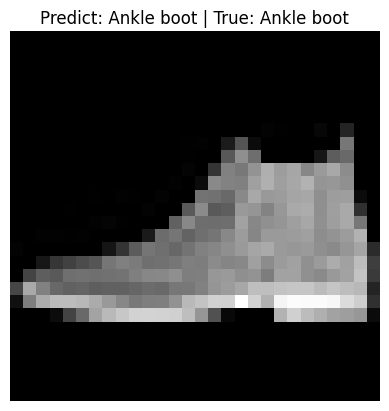

In [89]:
import tensorflow as tf
from tensorflow import keras
from keras import layers
import matplotlib.pyplot as plt
import numpy as np

# Load dữ liệu Fashion-MNIST
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

# Tiền xử lý dữ liệu
X_train = X_train.astype("float32") / 255
X_test = X_test.astype("float32") / 255

X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

# Xây dựng mô hình CNN
model = keras.Sequential([
    keras.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Compile
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1
)

# Đánh giá trên tập test
loss, accuracy = model.evaluate(X_test, y_test)

print("Test loss:", loss)
print("Test accuracy:", accuracy)

# Dự đoán thử 1 ảnh
index = 0

predict = model.predict(X_test[index:index+1])

pred_label = np.argmax(predict)
true_label = np.argmax(y_test[index])

print("Dự đoán:", pred_label, "-", class_names[pred_label])
print("Nhãn thật:", true_label, "-", class_names[true_label])

plt.imshow(X_test[index].reshape(28, 28), cmap='gray')
plt.title("Predict: " + class_names[pred_label] + " | True: " + class_names[true_label])
plt.axis("off")
plt.show()

Du doan anh khac

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
Dự đoán: 1 - Trouser
Nhãn thật: 1 - Trouser


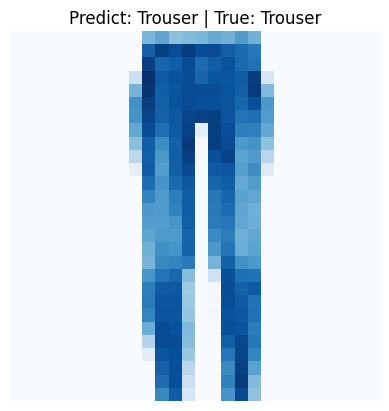

In [105]:
index = 728

predict = model.predict(X_test[index:index+1])

pred_label = np.argmax(predict)
true_label = np.argmax(y_test[index])

print("Dự đoán:", pred_label, "-", class_names[pred_label])
print("Nhãn thật:", true_label, "-", class_names[true_label])

plt.imshow(X_test[index].reshape(28, 28), cmap='Blues')
plt.title("Predict: " + class_names[pred_label] + " | True: " + class_names[true_label])
plt.axis("off")
plt.show()

#======================================================================


#Chương trình cài đặt CNN để nhận dạng ảnh khuôn mặt {Nam, Nữ}